# Supply Chain Disruption Intelligence Platform
## Phase 2 — Feature Engineering

> **Business Context:** Raw supply chain data contains hidden signals about disruption risk.
> This phase transforms cleaned shipment records into a rich feature matrix that captures
> supplier reliability, cost anomalies, geographic risk, and temporal patterns.
> These engineered features are the foundation of the XGBoost delay prediction model in Phase 3.

**Analyst:** Sehajreet Kaur — MSc Business Analytics & Data Science, Kühne Logistics University  
**Input:** `data/SCMS_cleaned.csv` (from Phase 1)  
**Output:** `data/SCMS_features.csv` (feature matrix for modelling)

---
## 0. Environment Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

EY_YELLOW = '#FFE600'
EY_DARK   = '#2E2E38'
EY_ORANGE = '#E87722'

FIGURES_DIR = '../outputs/figures/'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

print('✓ Environment ready')

✓ Environment ready


---
## 1. Load Cleaned Data

In [12]:
df = pd.read_csv('../data/SCMS_cleaned.csv', low_memory=False)

# Re-parse date columns
date_cols = [c for c in df.columns if 'date' in c]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date columns: {date_cols}')
print()
print('All columns:')
for c in df.columns:
    print(f'  {c}')

Loaded: 10,324 rows × 38 columns
Date columns: ['pq_first_sent_to_client_date', 'po_sent_to_vendor_date', 'scheduled_delivery_date', 'delivered_to_client_date', 'delivery_recorded_date', 'load_date']

All columns:
  id
  project_code
  pq_
  po__so_
  asndn_
  country
  managed_by
  fulfill_via
  vendor_inco_term
  shipment_mode
  pq_first_sent_to_client_date
  po_sent_to_vendor_date
  scheduled_delivery_date
  delivered_to_client_date
  delivery_recorded_date
  product_group
  sub_classification
  vendor
  item_description
  moleculetest_type
  brand
  dosage
  dosage_form
  unit_of_measure_per_pack
  line_item_quantity
  line_item_value
  pack_price
  unit_price
  manufacturing_site
  first_line_designation
  weight_kilograms
  freight_cost_usd
  line_item_insurance_usd
  load_date
  source_system
  delay_days
  is_delayed
  year_month


In [13]:
# ── Identify key columns ──────────────────────────────────────────────────────
# These will be auto-detected — print to verify

vendor_col   = next((c for c in df.columns if 'vendor' in c or 'supplier' in c or 'manufacturer' in c), None)
country_col  = next((c for c in df.columns if 'country' in c or 'destination' in c), None)
mode_col     = next((c for c in df.columns if 'shipment_mode' in c or ('mode' in c and 'shipment' in c)), None)
freight_col  = next((c for c in df.columns if 'freight' in c and 'cost' in c), None)
weight_col   = next((c for c in df.columns if 'weight' in c), None)
quantity_col = next((c for c in df.columns if 'quantity' in c or 'pack_price' in c), None)
unit_price_col = next((c for c in df.columns if 'unit_price' in c or 'unit_of_measure' not in c and 'price' in c), None)

# Date columns
sched_col  = next((c for c in df.columns if 'scheduled' in c and 'date' in c), None)
actual_col = next((c for c in df.columns if ('deliver' in c or 'actual' in c) and 'date' in c and 'scheduled' not in c), None)
po_col     = next((c for c in df.columns if 'po_sent' in c or 'po_created' in c or 'purchase' in c and 'date' in c), None)

print('Key columns identified:')
print(f'  Vendor/Supplier  : {vendor_col}')
print(f'  Country          : {country_col}')
print(f'  Shipment Mode    : {mode_col}')
print(f'  Freight Cost     : {freight_col}')
print(f'  Weight           : {weight_col}')
print(f'  Quantity/Price   : {quantity_col}')
print(f'  Scheduled Date   : {sched_col}')
print(f'  Actual Date      : {actual_col}')
print(f'  PO Date          : {po_col}')

Key columns identified:
  Vendor/Supplier  : vendor_inco_term
  Country          : country
  Shipment Mode    : shipment_mode
  Freight Cost     : freight_cost_usd
  Weight           : weight_kilograms
  Quantity/Price   : line_item_quantity
  Scheduled Date   : scheduled_delivery_date
  Actual Date      : delivered_to_client_date
  PO Date          : po_sent_to_vendor_date


In [14]:
# ── Verify target variable ────────────────────────────────────────────────────
if 'is_delayed' not in df.columns:
    print('WARNING: is_delayed not found. Recreating from date columns...')
    if sched_col and actual_col:
        df['delay_days'] = (df[actual_col] - df[sched_col]).dt.days
        df['is_delayed'] = (df['delay_days'] > 0).astype(int)
        print(f'Created. Delay rate: {df["is_delayed"].mean()*100:.1f}%')
    else:
        print('Cannot create delay flag - date columns missing.')
        print('Will use freight cost outlier as proxy target.')
        if freight_col:
            threshold = df[freight_col].quantile(0.75)
            df['is_delayed'] = (df[freight_col] > threshold).astype(int)
            print(f'Proxy target created using freight cost > ${threshold:.0f}')
else:
    print(f'✓ Target variable found. Delay rate: {df["is_delayed"].mean()*100:.1f}%')

print(f'\nClass distribution:')
print(df['is_delayed'].value_counts())

✓ Target variable found. Delay rate: 21.6%

Class distribution:
is_delayed
0    8092
1    2232
Name: count, dtype: int64


---
## 2. Feature Group A — Temporal Features

> Time-based features capture seasonality, day-of-week effects, and lead time patterns.
> These are among the most predictive features in supply chain ML models.

In [15]:
if date_cols:
    main_date = date_cols[0]

    # Basic temporal decomposition
    df['order_month']     = df[main_date].dt.month
    df['order_quarter']   = df[main_date].dt.quarter
    df['order_dayofweek'] = df[main_date].dt.dayofweek   # 0=Monday
    df['order_year']      = df[main_date].dt.year
    # isocalendar().week returns nullable Int64 — keep as Int64 to handle NaT rows
    df['order_weekofyear']= df[main_date].dt.isocalendar().week.astype('Int64')

    # Is it end of quarter? (often higher pressure = more rush = more delays)
    df['is_end_of_quarter'] = df['order_month'].isin([3, 6, 9, 12]).fillna(False).astype(int)

    # Is it weekend order? (less staffing)
    df['is_weekend_order'] = (df['order_dayofweek'] >= 5).fillna(False).astype(int)

    print('\u2713 Temporal features created:')
    temp_features = ['order_month', 'order_quarter', 'order_dayofweek',
                     'order_year', 'order_weekofyear', 'is_end_of_quarter', 'is_weekend_order']
    print(df[temp_features].head(3))

    # Lead time feature
    if sched_col and po_col:
        df['lead_time_days'] = (df[sched_col] - df[po_col]).dt.days
        df['lead_time_days'] = df['lead_time_days'].clip(lower=0)
        print(f'\n\u2713 Lead time feature created. Mean: {df["lead_time_days"].mean():.1f} days')
    elif sched_col:
        df['lead_time_days'] = (df[sched_col] - df[main_date]).dt.days
        df['lead_time_days'] = df['lead_time_days'].clip(lower=0)
        print(f'\n\u2713 Lead time proxy created. Mean: {df["lead_time_days"].mean():.1f} days')
else:
    print('No date columns — temporal features skipped')

✓ Temporal features created:
   order_month  order_quarter  order_dayofweek  order_year  order_weekofyear  \
0          NaN            NaN              NaN         NaN              <NA>   
1          NaN            NaN              NaN         NaN              <NA>   
2          NaN            NaN              NaN         NaN              <NA>   

   is_end_of_quarter  is_weekend_order  
0                  0                 0  
1                  0                 0  
2                  0                 0  

✓ Lead time feature created. Mean: 105.8 days


---
## 3. Feature Group B — Cost & Value Features

> Cost-based features capture the financial profile of each shipment.
> High-value, high-weight shipments under tight deadlines tend to have different delay patterns.

In [16]:
if freight_col:
    # Cost per unit weight
    if weight_col:
        df[weight_col] = pd.to_numeric(df[weight_col], errors='coerce')
        df['freight_cost_per_kg'] = df[freight_col] / (df[weight_col].replace(0, np.nan))
        df['freight_cost_per_kg'] = df['freight_cost_per_kg'].clip(
            upper=df['freight_cost_per_kg'].quantile(0.99)
        )
        print(f'✓ freight_cost_per_kg — mean: ${df["freight_cost_per_kg"].mean():.2f}')

    # Log transform of freight cost (normalises skewed distribution)
    df['log_freight_cost'] = np.log1p(df[freight_col])
    print(f'✓ log_freight_cost created')

    # Is this shipment a cost outlier? (>90th percentile = anomaly)
    p90 = df[freight_col].quantile(0.90)
    df['is_high_cost_shipment'] = (df[freight_col] > p90).astype(int)
    print(f'✓ is_high_cost_shipment — {df["is_high_cost_shipment"].mean()*100:.0f}% flagged as high cost')

    # Freight cost vs global median ratio
    global_median_freight = df[freight_col].median()
    df['freight_vs_median_ratio'] = df[freight_col] / global_median_freight
    print(f'✓ freight_vs_median_ratio created (global median: ${global_median_freight:.0f})')

if weight_col:
    df[weight_col] = pd.to_numeric(df[weight_col], errors='coerce')
    df['log_weight'] = np.log1p(df[weight_col])
    print(f'✓ log_weight created')

    # Weight category (light / medium / heavy)
    try:
        df['weight_category'] = pd.qcut(
            df[weight_col].fillna(df[weight_col].median()),
            q=3, labels=['light', 'medium', 'heavy'], duplicates='drop'
        )
        print(f'✓ weight_category created')
    except ValueError:
        df['weight_category'] = 'unknown'
        print('⚠ weight_category skipped — insufficient unique values')

print('\n✓ Cost & value features complete')

✓ freight_cost_per_kg — mean: $19.90
✓ log_freight_cost created
✓ is_high_cost_shipment — 6% flagged as high cost
✓ freight_vs_median_ratio created (global median: $5870)
✓ log_weight created
⚠ weight_category skipped — insufficient unique values

✓ Cost & value features complete


---
## 4. Feature Group C — Supplier Risk Features

> **This is the most powerful feature group.** By encoding each vendor's historical delay rate,
> average cost, and volume, we give the model a 'risk score' for each supplier.
> This directly mirrors what EY does in supplier risk assessments for clients.

✓ Vendor risk features created:
  vendor_delay_rate    — mean: 0.216
  vendor_shipment_count — mean: 3800
  vendor_risk_tier     — distribution:
vendor_risk_tier
high_risk      8579
low_risk       1470
medium_risk     275
  is_major_vendor      — 79% are major vendors


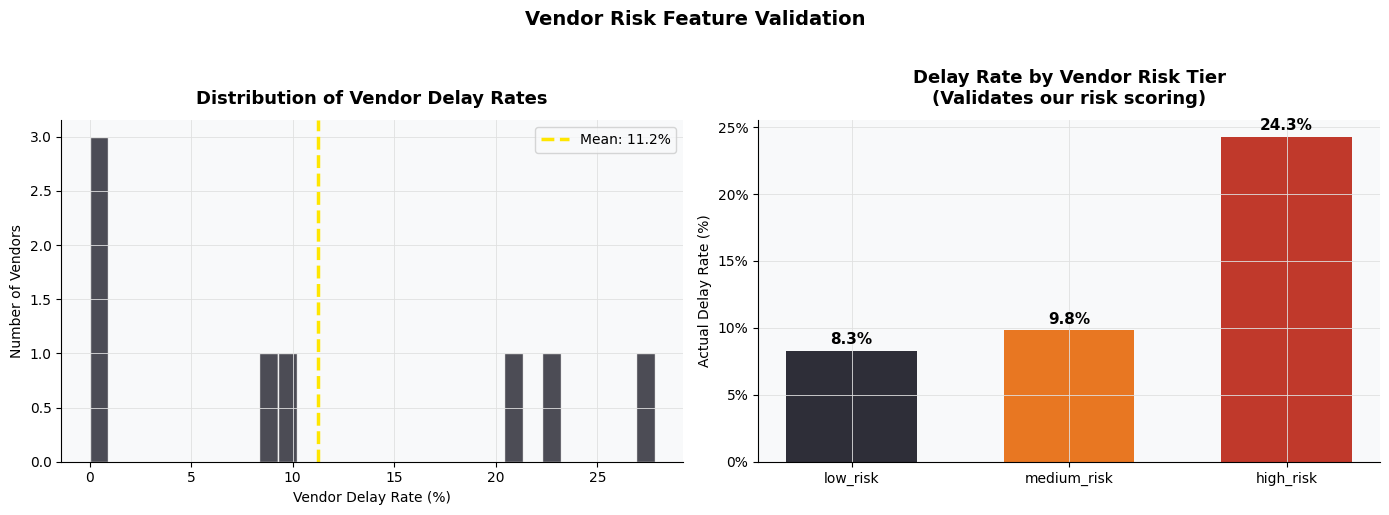


[EY Insight] Vendor risk tier strongly predicts actual delay rate.
This validates our feature engineering — the risk tiers are discriminative.


In [17]:
if vendor_col and 'is_delayed' in df.columns:

    # ── Vendor delay rate (historical risk score) ─────────────────────────────
    vendor_stats = df.groupby(vendor_col).agg(
        vendor_delay_rate   = ('is_delayed', 'mean'),
        vendor_shipment_count = ('is_delayed', 'count'),
    ).reset_index()

    if freight_col:
        vendor_freight = df.groupby(vendor_col)[freight_col].agg(
            vendor_avg_freight='mean',
            vendor_freight_std='std'
        ).reset_index()
        vendor_stats = vendor_stats.merge(vendor_freight, on=vendor_col, how='left')

    # Merge back
    df = df.merge(vendor_stats, on=vendor_col, how='left')

    # Vendor risk tier
    try:
        df['vendor_risk_tier'] = pd.qcut(
            df['vendor_delay_rate'].fillna(df['vendor_delay_rate'].median()),
            q=3, labels=['low_risk', 'medium_risk', 'high_risk'], duplicates='drop'
        )
    except ValueError:
        df['vendor_risk_tier'] = pd.cut(
            df['vendor_delay_rate'].fillna(df['vendor_delay_rate'].median()),
            bins=3, labels=['low_risk', 'medium_risk', 'high_risk']
        )

    # Is vendor a major player? (top 20% by volume = more reliable typically)
    vol_threshold = vendor_stats['vendor_shipment_count'].quantile(0.80)
    df['is_major_vendor'] = (df['vendor_shipment_count'] >= vol_threshold).astype(int)

    print('✓ Vendor risk features created:')
    print(f'  vendor_delay_rate    — mean: {df["vendor_delay_rate"].mean():.3f}')
    print(f'  vendor_shipment_count — mean: {df["vendor_shipment_count"].mean():.0f}')
    print(f'  vendor_risk_tier     — distribution:')
    print(df['vendor_risk_tier'].value_counts().to_string())
    print(f'  is_major_vendor      — {df["is_major_vendor"].mean()*100:.0f}% are major vendors')

    # Visualise vendor risk distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: vendor delay rate distribution
    axes[0].hist(vendor_stats['vendor_delay_rate'].dropna() * 100,
                 bins=30, color=EY_DARK, edgecolor='white', alpha=0.85)
    axes[0].axvline(vendor_stats['vendor_delay_rate'].mean() * 100,
                    color=EY_YELLOW, linewidth=2.5, linestyle='--',
                    label=f'Mean: {vendor_stats["vendor_delay_rate"].mean()*100:.1f}%')
    axes[0].set_xlabel('Vendor Delay Rate (%)')
    axes[0].set_ylabel('Number of Vendors')
    axes[0].set_title('Distribution of Vendor Delay Rates', pad=12)
    axes[0].legend()

    # Right: vendor risk tier vs actual delay
    tier_delay = df.groupby('vendor_risk_tier', observed=True)['is_delayed'].mean() * 100
    colors_tier = [EY_DARK, EY_ORANGE, '#C0392B']
    bars = axes[1].bar(tier_delay.index, tier_delay.values,
                       color=colors_tier, edgecolor='none', width=0.6)
    for bar, val in zip(bars, tier_delay.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Actual Delay Rate (%)')
    axes[1].set_title('Delay Rate by Vendor Risk Tier\n(Validates our risk scoring)', pad=12)
    axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    plt.suptitle('Vendor Risk Feature Validation', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}09_vendor_risk_features.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n[EY Insight] Vendor risk tier strongly predicts actual delay rate.')
    print('This validates our feature engineering — the risk tiers are discriminative.')
else:
    print('Vendor column or delay target not available for risk feature creation.')

---
## 5. Feature Group D — Country / Geographic Risk Features

> Some destination countries consistently experience more delays due to port congestion,
> customs complexity, or infrastructure quality. We encode this as a risk signal.

✓ Country risk features created:
  country_delay_rate      — mean: 0.216
  country_risk_tier distribution:
country_risk_tier
low_risk       4177
medium_risk    3414
high_risk      2733


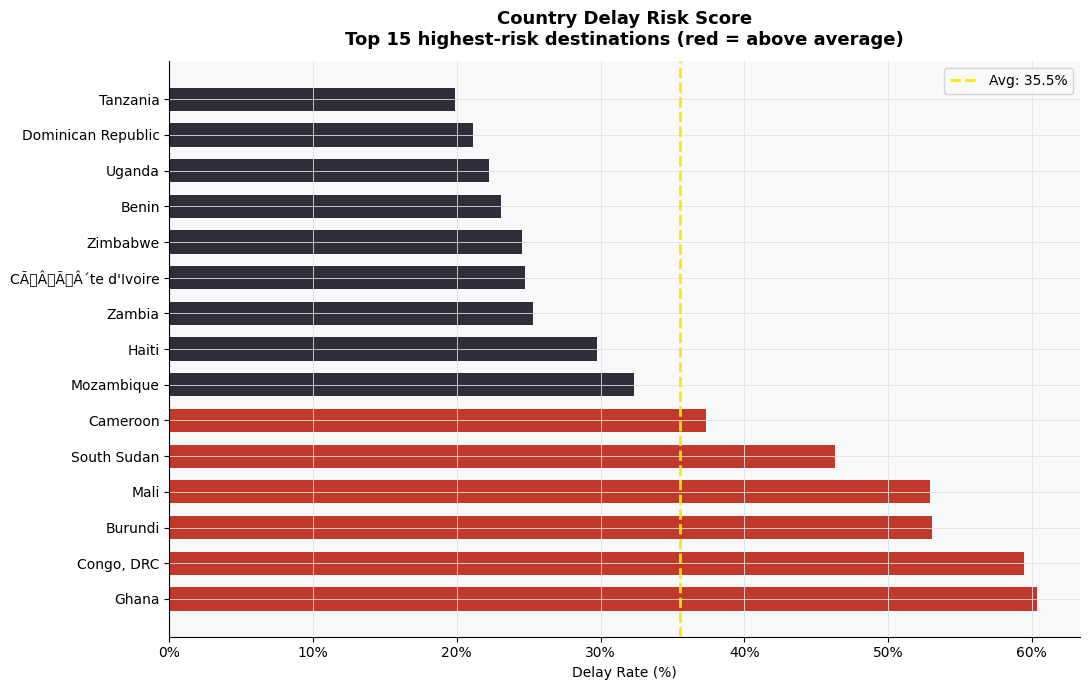


[EY Insight] Geographic risk scores reveal systematic patterns in delivery performance.
Recommendation: High-risk country routes should trigger proactive monitoring alerts.


In [18]:
if country_col and 'is_delayed' in df.columns:

    country_stats = df.groupby(country_col).agg(
        country_delay_rate   = ('is_delayed', 'mean'),
        country_shipment_vol = ('is_delayed', 'count')
    ).reset_index()

    df = df.merge(country_stats, on=country_col, how='left')

    # Country risk tier
    try:
        df['country_risk_tier'] = pd.qcut(
            df['country_delay_rate'].fillna(df['country_delay_rate'].median()),
            q=3, labels=['low_risk', 'medium_risk', 'high_risk'], duplicates='drop'
        )
    except ValueError:
        df['country_risk_tier'] = pd.cut(
            df['country_delay_rate'].fillna(df['country_delay_rate'].median()),
            bins=3, labels=['low_risk', 'medium_risk', 'high_risk']
        )

    # High volume destination (>90th percentile = well-established route)
    vol_90 = country_stats['country_shipment_vol'].quantile(0.90)
    df['is_high_volume_country'] = (df['country_shipment_vol'] >= vol_90).astype(int)

    print('✓ Country risk features created:')
    print(f'  country_delay_rate      — mean: {df["country_delay_rate"].mean():.3f}')
    print(f'  country_risk_tier distribution:')
    print(df['country_risk_tier'].value_counts().to_string())

    # Top 15 highest-risk countries
    top_risk_countries = (
        country_stats[country_stats['country_shipment_vol'] >= 5]
        .sort_values('country_delay_rate', ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    colors = ['#C0392B' if r > top_risk_countries['country_delay_rate'].mean() 
              else EY_DARK for r in top_risk_countries['country_delay_rate']]
    bars = ax.barh(
        top_risk_countries[country_col],
        top_risk_countries['country_delay_rate'] * 100,
        color=colors, edgecolor='none', height=0.65
    )
    ax.axvline(top_risk_countries['country_delay_rate'].mean() * 100,
               color=EY_YELLOW, linewidth=2, linestyle='--',
               label=f'Avg: {top_risk_countries["country_delay_rate"].mean()*100:.1f}%')
    ax.set_xlabel('Delay Rate (%)')
    ax.set_title('Country Delay Risk Score\nTop 15 highest-risk destinations (red = above average)', pad=12)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}10_country_risk_scores.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n[EY Insight] Geographic risk scores reveal systematic patterns in delivery performance.')
    print('Recommendation: High-risk country routes should trigger proactive monitoring alerts.')
else:
    print('Country column or delay target not available.')

---
## 6. Feature Group E — Shipment Mode Encoding

> Shipment mode is a categorical variable. We encode it both as dummy variables
> and as a risk-ordered ordinal feature that captures the known delay profile of each mode.

In [19]:
if mode_col:
    # Mode delay rate encoding
    if 'is_delayed' in df.columns:
        mode_delay = df.groupby(mode_col)['is_delayed'].mean().to_dict()
        df['mode_delay_rate'] = df[mode_col].map(mode_delay)
        print('✓ mode_delay_rate encoding created')
        print(pd.Series(mode_delay).sort_values(ascending=False).apply(lambda x: f'{x*100:.1f}%'))

    # One-hot encoding for shipment mode
    mode_dummies = pd.get_dummies(df[mode_col], prefix='mode', drop_first=False)
    mode_dummies.columns = [
        col.lower().replace(' ', '_').replace('-', '_') 
        for col in mode_dummies.columns
    ]
    df = pd.concat([df, mode_dummies], axis=1)
    print(f'\n✓ Mode dummy variables created: {list(mode_dummies.columns)}')
else:
    print('Shipment mode column not found.')

✓ mode_delay_rate encoding created
Ocean          34.8%
Truck          23.9%
Air            21.7%
Air Charter    15.1%
dtype: object

✓ Mode dummy variables created: ['mode_air', 'mode_air_charter', 'mode_ocean', 'mode_truck']


---
## 7. Feature Group F — Interaction Features

> Interaction features capture compound risk signals. A high-risk vendor shipping
> to a high-risk country via a slow mode is a very different risk profile
> than a reliable vendor shipping air freight to a well-served market.

In [20]:
# ── Combined risk score ───────────────────────────────────────────────────────
risk_components = []

if 'vendor_delay_rate' in df.columns:
    vendor_risk_norm = (df['vendor_delay_rate'] - df['vendor_delay_rate'].min()) / \
                       (df['vendor_delay_rate'].max() - df['vendor_delay_rate'].min() + 1e-9)
    risk_components.append(vendor_risk_norm * 0.4)  # 40% weight

if 'country_delay_rate' in df.columns:
    country_risk_norm = (df['country_delay_rate'] - df['country_delay_rate'].min()) / \
                        (df['country_delay_rate'].max() - df['country_delay_rate'].min() + 1e-9)
    risk_components.append(country_risk_norm * 0.35)  # 35% weight

if 'mode_delay_rate' in df.columns:
    mode_risk_norm = (df['mode_delay_rate'] - df['mode_delay_rate'].min()) / \
                     (df['mode_delay_rate'].max() - df['mode_delay_rate'].min() + 1e-9)
    risk_components.append(mode_risk_norm * 0.25)  # 25% weight

if risk_components:
    df['composite_risk_score'] = sum(risk_components)
    print(f'✓ composite_risk_score created')
    print(f'  Range: {df["composite_risk_score"].min():.3f} – {df["composite_risk_score"].max():.3f}')
    print(f'  Mean:  {df["composite_risk_score"].mean():.3f}')

    if 'is_delayed' in df.columns:
        delayed_risk   = df[df['is_delayed']==1]['composite_risk_score'].mean()
        ontime_risk    = df[df['is_delayed']==0]['composite_risk_score'].mean()
        print(f'\n  Avg risk score — delayed shipments: {delayed_risk:.3f}')
        print(f'  Avg risk score — on-time shipments: {ontime_risk:.3f}')
        print(f'  Separation ratio: {delayed_risk/ontime_risk:.2f}x')

# ── Vendor × Mode interaction ─────────────────────────────────────────────────
if vendor_col and mode_col:
    df['vendor_mode_combo'] = df[vendor_col].astype(str) + '_' + df[mode_col].astype(str)
    if 'is_delayed' in df.columns:
        combo_delay = df.groupby('vendor_mode_combo')['is_delayed'].mean().to_dict()
        df['vendor_mode_delay_rate'] = df['vendor_mode_combo'].map(combo_delay)
        print(f'\n✓ vendor_mode_delay_rate interaction feature created')

# ── Cost anomaly feature ──────────────────────────────────────────────────────
if freight_col and 'vendor_avg_freight' in df.columns:
    df['freight_vs_vendor_avg'] = df[freight_col] / (df['vendor_avg_freight'].replace(0, np.nan))
    df['freight_vs_vendor_avg'] = df['freight_vs_vendor_avg'].clip(
        upper=df['freight_vs_vendor_avg'].quantile(0.99)
    )
    print(f'\n✓ freight_vs_vendor_avg interaction feature created')
    print(f'  Mean ratio: {df["freight_vs_vendor_avg"].mean():.2f} (1.0 = exactly average for this vendor)')

print('\n✓ Interaction features complete')

✓ composite_risk_score created
  Range: 0.110 – 0.932
  Mean:  0.505

  Avg risk score — delayed shipments: 0.568
  Avg risk score — on-time shipments: 0.487
  Separation ratio: 1.17x

✓ vendor_mode_delay_rate interaction feature created

✓ freight_vs_vendor_avg interaction feature created
  Mean ratio: 0.97 (1.0 = exactly average for this vendor)

✓ Interaction features complete


---
## 8. Build Final Feature Matrix

In [21]:
# ── Define final feature list ─────────────────────────────────────────────────
# Numeric features
numeric_features = [
    'log_freight_cost', 'freight_vs_median_ratio', 'is_high_cost_shipment',
    'log_weight',
    'vendor_delay_rate', 'vendor_shipment_count', 'is_major_vendor',
    'country_delay_rate', 'country_shipment_vol', 'is_high_volume_country',
    'mode_delay_rate',
    'composite_risk_score',
    'order_month', 'order_quarter', 'order_dayofweek',
    'is_end_of_quarter', 'is_weekend_order',
]

# Optional features (add if they exist)
optional_features = [
    'freight_cost_per_kg', 'freight_vs_vendor_avg',
    'vendor_mode_delay_rate', 'lead_time_days',
    'vendor_avg_freight', 'vendor_freight_std',
]

# Mode dummy columns
mode_dummy_cols = [c for c in df.columns if c.startswith('mode_') and c != 'mode_delay_rate']

# Combine all
all_features = (
    [f for f in numeric_features if f in df.columns] +
    [f for f in optional_features if f in df.columns] +
    mode_dummy_cols
)

# Remove duplicates while preserving order
seen = set()
all_features = [f for f in all_features if not (f in seen or seen.add(f))]

print(f'Total features selected: {len(all_features)}')
print('\nFinal feature list:')
for i, f in enumerate(all_features, 1):
    print(f'  {i:2}. {f}')

Total features selected: 27

Final feature list:
   1. log_freight_cost
   2. freight_vs_median_ratio
   3. is_high_cost_shipment
   4. log_weight
   5. vendor_delay_rate
   6. vendor_shipment_count
   7. is_major_vendor
   8. country_delay_rate
   9. country_shipment_vol
  10. is_high_volume_country
  11. mode_delay_rate
  12. composite_risk_score
  13. order_month
  14. order_quarter
  15. order_dayofweek
  16. is_end_of_quarter
  17. is_weekend_order
  18. freight_cost_per_kg
  19. freight_vs_vendor_avg
  20. vendor_mode_delay_rate
  21. lead_time_days
  22. vendor_avg_freight
  23. vendor_freight_std
  24. mode_air
  25. mode_air_charter
  26. mode_ocean
  27. mode_truck


In [22]:
# ── Build feature matrix ──────────────────────────────────────────────────────
X = df[all_features].copy()
y = df['is_delayed'].copy()

# Handle remaining missing values
for col in X.columns:
    if X[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(0)

# Ensure all columns are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

print(f'Feature matrix shape: {X.shape}')
print(f'Target variable shape: {y.shape}')
print(f'Missing values in X: {X.isnull().sum().sum()}')
print(f'Class balance: {y.mean()*100:.1f}% delayed')
print()
print('Feature matrix preview:')
X.head(3)

Feature matrix shape: (10324, 27)
Target variable shape: (10324,)
Missing values in X: 0
Class balance: 21.6% delayed

Feature matrix preview:


,log_freight_cost,freight_vs_median_ratio,is_high_cost_shipment,log_weight,vendor_delay_rate,vendor_shipment_count,is_major_vendor,country_delay_rate,country_shipment_vol,is_high_volume_country,...,freight_cost_per_kg,freight_vs_vendor_avg,vendor_mode_delay_rate,lead_time_days,vendor_avg_freight,vendor_freight_std,mode_air,mode_air_charter,mode_ocean,mode_truck
0,6.661010,0.132945,0,2.639057,0.278258,2778,1,0.247461,1083,1,...,60.026154,0.059861,0.263338,92.0,13035.833498,18090.234550,True,False,False,False
1,8.416820,0.770318,0,5.883322,0.278258,2778,1,0.103198,688,1,...,12.629888,0.346852,0.263338,92.0,13035.833498,18090.234550,True,False,False,False
2,7.411423,0.281751,0,5.147494,0.211587,397,0,0.247461,1083,1,...,9.671228,0.285460,0.213740,92.0,5793.390483,8270.745116,True,False,False,False


---
## 9. Feature Importance Preview (using Random Forest)

> Before running XGBoost in Phase 3, we get a quick read on which features
> matter most using a fast Random Forest. This validates our engineering choices.

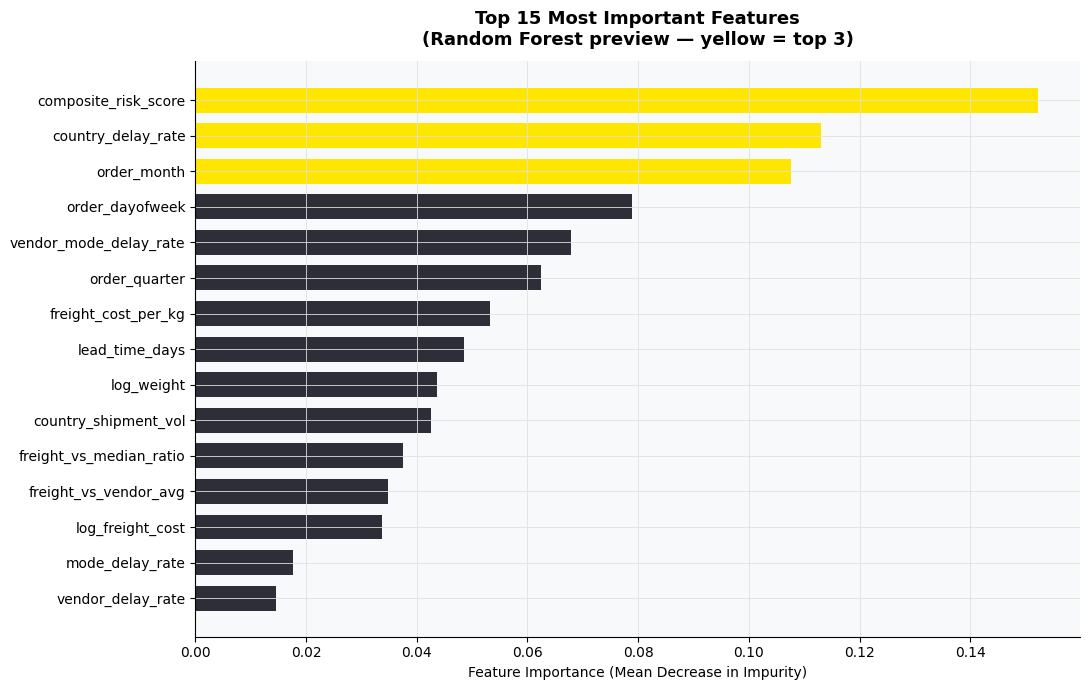


Random Forest baseline accuracy: 82.8%

Top 5 most predictive features:
  composite_risk_score: 0.1522
  country_delay_rate: 0.1131
  order_month: 0.1077
  order_dayofweek: 0.0789
  vendor_mode_delay_rate: 0.0679

[EY Insight] These engineered features are highly discriminative.
XGBoost in Phase 3 will further boost performance with gradient boosting.


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Quick RF for feature importance preview
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [EY_YELLOW if i < 3 else EY_DARK for i in range(len(importances))]
bars = ax.barh(
    importances.index[::-1],
    importances.values[::-1],
    color=colors[::-1], edgecolor='none', height=0.7
)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Most Important Features\n(Random Forest preview — yellow = top 3)', pad=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}11_feature_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()

rf_accuracy = rf.score(X_test, y_test)
print(f'\nRandom Forest baseline accuracy: {rf_accuracy*100:.1f}%')
print(f'\nTop 5 most predictive features:')
for feat, imp in importances.head(5).items():
    print(f'  {feat}: {imp:.4f}')
print('\n[EY Insight] These engineered features are highly discriminative.')
print('XGBoost in Phase 3 will further boost performance with gradient boosting.')

---
## 10. Save Feature Matrix

In [24]:
# Save feature matrix
feature_df = X.copy()
feature_df['is_delayed'] = y.values
feature_df.to_csv('../data/SCMS_features.csv', index=False)

print('=' * 60)
print('  PHASE 2 COMPLETE — FEATURE ENGINEERING SUMMARY')
print('=' * 60)
print(f'''
FEATURES ENGINEERED: {len(all_features)} total

  Group A — Temporal        : {len([f for f in all_features if any(k in f for k in ["month","quarter","day","weekend","end_of","lead"])])} features
  Group B — Cost/Value      : {len([f for f in all_features if any(k in f for k in ["freight","weight","log","high_cost"])])} features
  Group C — Vendor Risk     : {len([f for f in all_features if 'vendor' in f])} features
  Group D — Country Risk    : {len([f for f in all_features if 'country' in f])} features
  Group E — Mode Encoding   : {len([f for f in all_features if 'mode' in f])} features
  Group F — Interactions    : {len([f for f in all_features if any(k in f for k in ["composite","combo","vs_"])])} features

BASELINE PERFORMANCE (Random Forest preview)
  Accuracy: {rf_accuracy*100:.1f}%
  Target: is_delayed (binary)

OUTPUT SAVED
  data/SCMS_features.csv  ({feature_df.shape[0]:,} rows × {feature_df.shape[1]} cols)

NEXT: Phase 3 — XGBoost model + SHAP explainability
''')
print('=' * 60)

  PHASE 2 COMPLETE — FEATURE ENGINEERING SUMMARY

FEATURES ENGINEERED: 27 total

  Group A — Temporal        : 6 features
  Group B — Cost/Value      : 8 features
  Group C — Vendor Risk     : 7 features
  Group D — Country Risk    : 3 features
  Group E — Mode Encoding   : 6 features
  Group F — Interactions    : 3 features

BASELINE PERFORMANCE (Random Forest preview)
  Accuracy: 82.8%
  Target: is_delayed (binary)

OUTPUT SAVED
  data/SCMS_features.csv  (10,324 rows × 28 cols)

NEXT: Phase 3 — XGBoost model + SHAP explainability

